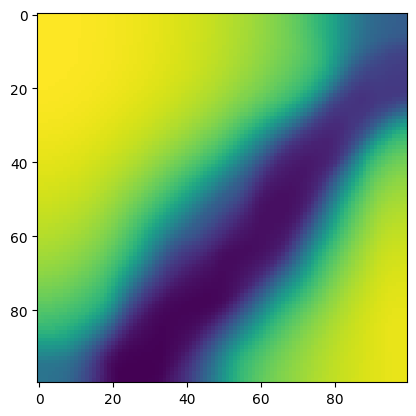

In [68]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

sys.path.append('C:\\Users\\Mark\\PycharmProjects\\approximationMap')

from control.experiment_data import ExperimentData

ex = ExperimentData()
ex.get_experiment_data('diesel', 'steam', 'CO')
surface = ex.get_rbf_data()[2]

diffs = np.abs(surface[5:] - surface[:-5])
plt.imshow(surface)

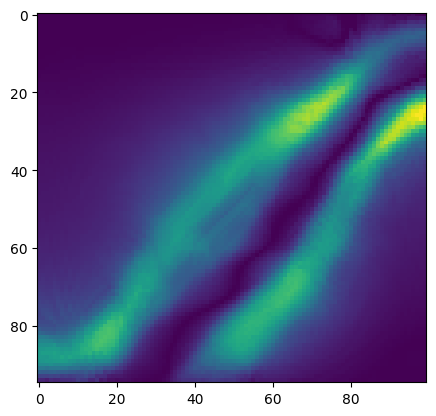

In [10]:
plt.imshow(diffs)
df = pd.DataFrame(diffs)

In [64]:
flag = 0
x = []
y = []

for i, row in enumerate(diffs):
    for k, val in enumerate(row):
        if val > 120 and flag == 0:
            flag = 1
        elif val < 5 and flag == 1:
            flag = 2
        elif val > 120 and flag == 2:
            x.append(k)
            y.append(i)
            flag = 0
    flag = 0

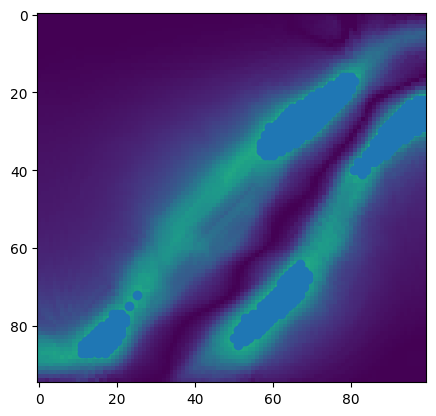

In [63]:
i = np.where(diffs > 120)

plt.scatter(i[1], i[0])
plt.imshow(diffs)

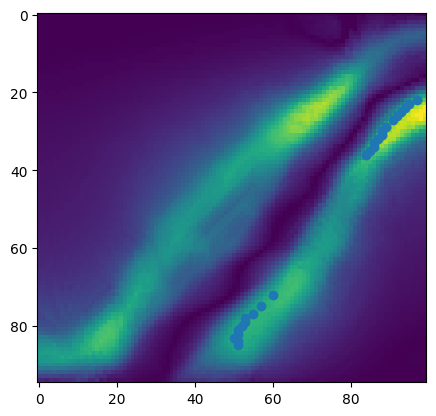

In [67]:
plt.scatter(x, y)
plt.imshow(diffs)

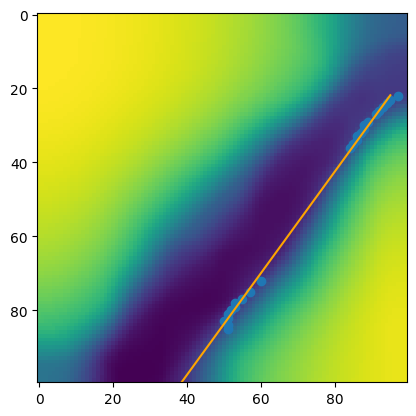

In [79]:
def linear(x, a, b):
    return a * x + b

params, _ = curve_fit(linear, x, y)
a, b = params

x_ = np.linspace(0, len(diffs))
y_ = linear(x_, a, b)

plt.scatter(x, y)
plt.plot(x_, y_, c='orange')
plt.imshow(surface)